for each variable or group do its own cluster
overlay into one big cluster.
boost dataset

Include sealevel to flood sensitivity in the clustering?

PLAN
- cluster all indiscrete ones (like waves)
- cluster groups: coastal characterices, atmospheric (mean, max etc)
- atmospheric group: ERA5 daily mean: 40 year period reduce dimensionality.
write a lil report featuring group clusters

In [1]:
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Load the CSV file into a DataFrame
df = pd.read_csv("filtered_combined_data.csv")

# List the columns of the DataFrame
print(df.columns)

Index(['latitude', 'longitude', 'CoastType', 'CVI', 'Name_closest',
       'Notes_closest', 'Info_closest', 'Wave_NC', 'Wave_Atlantic', 'Current'],
      dtype='object')


In [2]:
select_df = df[['latitude', 'longitude', 'CoastType', 'CVI',
       'Wave_NC', 'Wave_Atlantic', 'Current']]

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_94839/2911416662.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  select_df['CVI'] = select_df['CVI'].astype('category')
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_94839/2911416662.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  select_df['CoastType'] = select_df['CoastType'].astype('category')


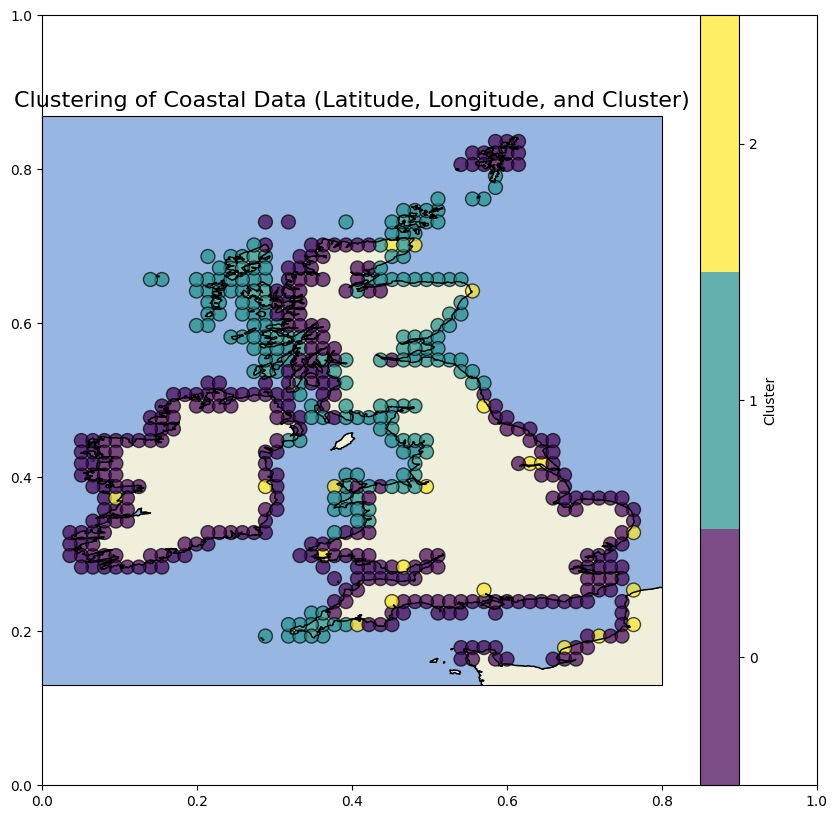

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select relevant columns for clustering (without latitude and longitude)
select_df = df[['latitude', 'longitude', 'CoastType', 'CVI', 'Wave_NC', 'Wave_Atlantic', 'Current']]

# Convert 'CVI' and 'CoastType' to categorical (if not already)
select_df['CVI'] = select_df['CVI'].astype('category')
select_df['CoastType'] = select_df['CoastType'].astype('category')

# One-hot encode 'CVI' and 'CoastType' columns
select_df_encoded = pd.get_dummies(select_df, columns=['CVI', 'CoastType'], drop_first=True)

# Drop latitude and longitude for clustering
select_df_cluster = select_df_encoded.drop(columns=['latitude', 'longitude'])

# Standardize the data (important for KMeans clustering)
scaler = StandardScaler()
select_df_scaled = scaler.fit_transform(select_df_cluster)

# Perform KMeans clustering (choose the number of clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
select_df_encoded['Cluster'] = kmeans.fit_predict(select_df_scaled)


import cartopy.crs as ccrs
import cartopy.feature as cfeature


# Set the number of clusters (you can adjust this based on the number of unique clusters)
n_clusters = select_df_encoded['Cluster'].nunique()

# Define a discrete color map (using 'viridis' here as an example)
cmap = plt.cm.viridis

# Set up the map projection (e.g., PlateCarree is a common projection for lat/lon)
fig, ax = plt.subplots(figsize=(10, 10))

ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features (land, oceans, coastlines)
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Scatter plot of the points, using 'latitude' and 'longitude' for coordinates, and 'Cluster' for colors
scatter = ax.scatter(select_df_encoded['longitude'], select_df_encoded['latitude'], 
                     c=select_df_encoded['Cluster'], cmap=cmap, marker='o', edgecolors='k', s=100, alpha=0.7)

# Create a discrete colorbar
# Use BoundaryNorm to match the number of clusters
bounds = np.arange(-0.5, n_clusters + 0.5, 1)  # Create boundaries based on cluster number
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=n_clusters)

# Add the colorbar with discrete ticks
plt.colorbar(scatter, ax=ax, label='Cluster', boundaries=bounds, ticks=np.arange(n_clusters), orientation='vertical')

# Add a title and labels
plt.title('Clustering of Coastal Data (Latitude, Longitude, and Cluster)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the map
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_99264/2810440667.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  select_df['CVI'] = select_df['CVI'].astype('category')
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_99264/2810440667.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  select_df['CoastType'] = select_df['CoastType'].astype('category')


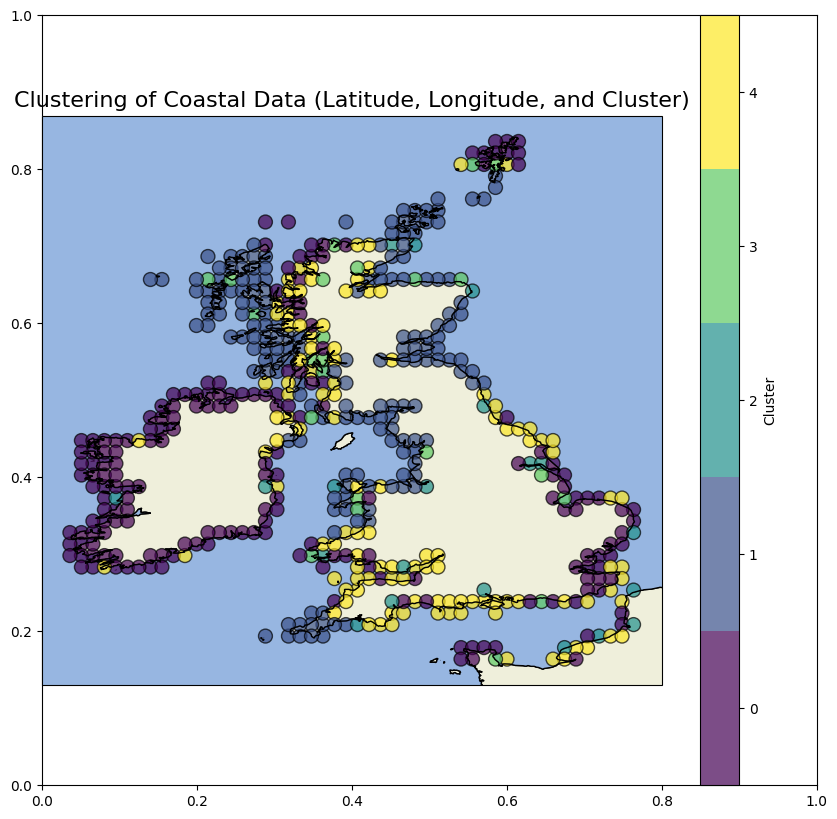

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select relevant columns for clustering (without latitude and longitude)
select_df = df[['latitude', 'longitude', 'CoastType', 'CVI', 'Wave_NC', 'Wave_Atlantic', 'Current']]

# Convert 'CVI' and 'CoastType' to categorical (if not already)
select_df['CVI'] = select_df['CVI'].astype('category')
select_df['CoastType'] = select_df['CoastType'].astype('category')

# One-hot encode 'CVI' and 'CoastType' columns
select_df_encoded = pd.get_dummies(select_df, columns=['CVI', 'CoastType'], drop_first=True)

# Drop latitude and longitude for clustering
select_df_cluster = select_df_encoded.drop(columns=['latitude', 'longitude'])

# Standardize the data (important for KMeans clustering)
scaler = StandardScaler()
select_df_scaled = scaler.fit_transform(select_df_cluster)

# Perform KMeans clustering (choose the number of clusters)
kmeans = KMeans(n_clusters=5, random_state=42)
select_df_encoded['Cluster'] = kmeans.fit_predict(select_df_scaled)


import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Set the number of clusters (you can adjust this based on the number of unique clusters)
n_clusters = select_df_encoded['Cluster'].nunique()

# Define a discrete color map (using 'viridis' here as an example)
cmap = plt.cm.viridis

# Set up the map projection (e.g., PlateCarree is a common projection for lat/lon)
fig, ax = plt.subplots(figsize=(10, 10))

ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features (land, oceans, coastlines)
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Scatter plot of the points, using 'latitude' and 'longitude' for coordinates, and 'Cluster' for colors
scatter = ax.scatter(select_df_encoded['longitude'], select_df_encoded['latitude'], 
                     c=select_df_encoded['Cluster'], cmap=cmap, marker='o', edgecolors='k', s=100, alpha=0.7)

# Create a discrete colorbar
# Use BoundaryNorm to match the number of clusters
bounds = np.arange(-0.5, n_clusters + 0.5, 1)  # Create boundaries based on cluster number
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=n_clusters)

# Add the colorbar with discrete ticks
plt.colorbar(scatter, ax=ax, label='Cluster', boundaries=bounds, ticks=np.arange(n_clusters), orientation='vertical')

# Add a title and labels
plt.title('Clustering of Coastal Data (Latitude, Longitude, and Cluster)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the map
plt.show()


In [13]:
# Group by the 'Cluster' and calculate the mean of each feature for each cluster
cluster_summary = select_df_encoded.groupby('Cluster')[['Wave_NC', 'Wave_Atlantic', 'Current']].mean()

# Print out the summary of factors for each cluster
print(cluster_summary)


          Wave_NC  Wave_Atlantic       Current
Cluster                                       
0        1.090909  -1.819691e+36  9.017083e+01
1        0.000000  -3.402823e+38 -3.382806e+38
2        0.750000  -8.507058e+37 -8.507058e+37
3        0.826087  -1.331539e+38 -1.479488e+38
4        1.672566   9.818319e+01  7.941926e+01
